# BEAD Model Improvement — RF Tuning, Gradient Boosting, and Better Stratification

### Goals
1. **Tune the Random Forest** — our RF uses near-default hyperparameters; systematic tuning may help
2. **Gradient Boosting** — builds trees *sequentially*, each correcting the previous tree's errors (vs RF which builds trees independently). Often outperforms RF because it focuses on hard-to-predict cases
3. **Better tech stratification** — instead of separate models (which fragment data), use interaction features that let a single model learn technology-specific patterns
4. **Compare everything** on the same train/test split

### RF vs Gradient Boosting
| | Random Forest | Gradient Boosting |
|---|---|---|
| Tree building | Independent (parallel) | Sequential (each corrects prior errors) |
| Aggregation | Average all trees equally | Weighted sum with learning rate |
| Bias-variance | Low bias, reduces variance | Reduces bias iteratively |
| Overfitting risk | Low (bagging) | Higher (must tune learning rate, depth) |
| Speed | Fast (parallelizable) | Slower (sequential) |

Target: `log1p(funding_per_location)`

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

Connected to BigQuery: broadband-data


In [2]:
# Load data (same as bead_rf_final)
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs, project_type, priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
       SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value AS FLOAT64) AS technology,
       AVG(CAST(low_latency AS INT64)) AS avg_latency
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}
df_nbm = client.query("""
SELECT state, COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fcc_nbm.nbm_hive` GROUP BY state
""").to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])

df_state_pop = client.query("""
SELECT stateabbr AS state, SUM(pop2020) AS state_population
FROM `broadband-data.fcc_block_level_pop.us2020` GROUP BY stateabbr
""").to_dataframe()

print(f'Projects: {df_projects.shape}, Locations: {df_locations.shape}')

Projects: (5251, 8), Locations: (5228, 4)


In [3]:
# Merge + feature engineering
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')
df = df.merge(df_state_pop, on='state', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology'] = df['technology'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population'] = df['state_population'].fillna(0)

df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)

df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

df['log_funding'] = np.log1p(df['funding_per_location'])
print(f'Samples: {df.shape[0]}')

Samples: 4962


## Feature Engineering: Technology Interactions
Instead of stratifying into separate models (which fragments data), create **interaction features** that let a single model learn technology-specific patterns.

- One-hot encode technology groups
- Create `miles_per_location × tech_dummy` interactions — lets the model learn different slopes for miles-vs-cost per technology

In [4]:
# Technology grouping (same as stratified notebook)
MIN_STRATUM = 50
tech_counts = df['technology'].value_counts()
small_techs = tech_counts[tech_counts < MIN_STRATUM].index.tolist()
df['tech_group'] = df['technology'].apply(lambda x: -1 if x in small_techs else x)

tech_labels = {
    -1: 'other', 40: 'hfc', 50: 'fiber', 61: 'code61', 71: 'lic_fw', 72: 'lbr_fw'
}

# One-hot encode technology groups
for code, label in tech_labels.items():
    df[f'tech_{label}'] = (df['tech_group'] == code).astype(int)

# Interaction features: miles_per_location × technology
for code, label in tech_labels.items():
    df[f'miles_x_{label}'] = df['miles_per_location'] * df[f'tech_{label}']

# Interaction features: jobs_per_location × technology
for code, label in tech_labels.items():
    df[f'jobs_x_{label}'] = df['jobs_per_location'] * df[f'tech_{label}']

print('Technology distribution:')
for code, label in tech_labels.items():
    n = df[f'tech_{label}'].sum()
    print(f'  {label}: {n} ({n/len(df)*100:.1f}%)')

print(f'\nInteraction features created: {len(tech_labels) * 2} (miles×tech + jobs×tech)')

Technology distribution:
  other: 33 (0.7%)
  hfc: 62 (1.2%)
  fiber: 2430 (49.0%)
  code61: 1831 (36.9%)
  lic_fw: 461 (9.3%)
  lbr_fw: 145 (2.9%)

Interaction features created: 12 (miles×tech + jobs×tech)


In [5]:
# Define feature sets for comparison
# Original 6 features (bead_rf_final baseline)
feat_original = [
    'miles_per_location', 'technology', 'jobs_per_location',
    'state_population', 'total_fiber_miles', 'state_num_providers',
]

# Enhanced: one-hot tech dummies + interactions (replace raw technology code)
tech_dummies = [f'tech_{label}' for label in tech_labels.values()]
miles_interactions = [f'miles_x_{label}' for label in tech_labels.values()]
jobs_interactions = [f'jobs_x_{label}' for label in tech_labels.values()]

feat_enhanced = (
    ['miles_per_location', 'jobs_per_location', 'state_population',
     'total_fiber_miles', 'state_num_providers']
    + tech_dummies
    + miles_interactions
    + jobs_interactions
)

print(f'Original features: {len(feat_original)}')
print(f'Enhanced features: {len(feat_enhanced)}')
print(f'  Base: 5, Tech dummies: {len(tech_dummies)}, Interactions: {len(miles_interactions) + len(jobs_interactions)}')

Original features: 6
Enhanced features: 23
  Base: 5, Tech dummies: 6, Interactions: 12


In [6]:
# Consistent train/test split for all experiments
y = df['log_funding']
X_orig = df[feat_original].fillna(0)
X_enh = df[feat_enhanced].fillna(0)

X_orig_train, X_orig_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state=42)
X_enh_train = df.loc[X_orig_train.index, feat_enhanced].fillna(0)
X_enh_test = df.loc[X_orig_test.index, feat_enhanced].fillna(0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred)))
    mae = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred))
    cv = cross_val_score(model, pd.concat([X_tr, X_te]), pd.concat([y_tr, y_te]), cv=kf, scoring='r2')
    print(f'{name}:')
    print(f'  R²={r2:.4f}  CV R²={cv.mean():.4f}±{cv.std():.4f}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}')
    return {'name': name, 'r2': r2, 'cv_r2': cv.mean(), 'cv_std': cv.std(),
            'rmse': rmse, 'mae': mae, 'model': model, 'y_pred': y_pred}

print(f'Train: {len(X_orig_train)}, Test: {len(X_orig_test)}')

Train: 3969, Test: 993


## 1. RF Baseline (current model)

In [7]:
results = []

# Current model: 200 trees, min_samples_split=5
r = evaluate(
    RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1),
    X_orig_train, X_orig_test, y_train, y_test,
    'RF Baseline (200 trees, 6 feat)'
)
results.append(r)

RF Baseline (200 trees, 6 feat):
  R²=0.7419  CV R²=0.7622±0.0176  RMSE=$2,491  MAE=$1,420


## 2. Tuned Random Forest
Search over key hyperparameters:
- `n_estimators`: more trees = more stable (diminishing returns past ~500)
- `max_depth`: limits tree complexity, prevents overfitting
- `max_features`: fraction of features considered at each split
- `min_samples_leaf`: minimum samples in a leaf node

In [8]:
# Randomized search for RF hyperparameters
rf_param_grid = {
    'n_estimators': [200, 500, 1000, 1500],
    'max_depth': [None, 10, 15, 20, 30],
    'max_features': [0.3, 0.5, 0.7, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid, n_iter=40, cv=kf, scoring='r2',
    random_state=42, n_jobs=1, verbose=0
)
rf_search.fit(X_orig_train, y_train)

print('Best RF hyperparameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'  CV R²: {rf_search.best_score_:.4f}')

Best RF hyperparameters:
  n_estimators: 1500
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: None
  CV R²: 0.7640


In [9]:
r = evaluate(
    rf_search.best_estimator_,
    X_orig_train, X_orig_test, y_train, y_test,
    'RF Tuned (6 feat)'
)
results.append(r)

RF Tuned (6 feat):
  R²=0.7502  CV R²=0.7705±0.0139  RMSE=$2,444  MAE=$1,399


## 3. RF with Tech Interaction Features

In [10]:
# Default params with enhanced features
r = evaluate(
    RandomForestRegressor(n_estimators=500, min_samples_split=5, random_state=42, n_jobs=-1),
    X_enh_train, X_enh_test, y_train, y_test,
    'RF + Tech Interactions (500 trees)'
)
results.append(r)

RF + Tech Interactions (500 trees):
  R²=0.7410  CV R²=0.7593±0.0184  RMSE=$2,488  MAE=$1,422


In [11]:
# Tuned RF with enhanced features
rf_enh_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid, n_iter=40, cv=kf, scoring='r2',
    random_state=42, n_jobs=1, verbose=0
)
rf_enh_search.fit(X_enh_train, y_train)

print('Best RF+interactions hyperparameters:')
for k, v in rf_enh_search.best_params_.items():
    print(f'  {k}: {v}')

r = evaluate(
    rf_enh_search.best_estimator_,
    X_enh_train, X_enh_test, y_train, y_test,
    'RF Tuned + Tech Interactions'
)
results.append(r)

Best RF+interactions hyperparameters:
  n_estimators: 1500
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: None


RF Tuned + Tech Interactions:
  R²=0.7488  CV R²=0.7645±0.0135  RMSE=$2,468  MAE=$1,413


## 4. Gradient Boosting (sklearn)
Sequential tree building — each tree learns from the previous tree's residuals.

Key hyperparameters:
- `learning_rate`: step size shrinkage (lower = more trees needed but better generalization)
- `n_estimators`: number of boosting stages
- `max_depth`: tree depth (typically shallow: 3-8, unlike RF which uses full depth)
- `subsample`: fraction of samples used per tree (adds randomness like RF)

In [12]:
# Gradient Boosting with original features
r = evaluate(
    GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=5,
                              subsample=0.8, random_state=42),
    X_orig_train, X_orig_test, y_train, y_test,
    'GBR Default (6 feat)'
)
results.append(r)

GBR Default (6 feat):
  R²=0.7331  CV R²=0.7511±0.0190  RMSE=$2,527  MAE=$1,466


In [13]:
# Tuned Gradient Boosting
gb_param_grid = {
    'n_estimators': [200, 500, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid, n_iter=40, cv=kf, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
gb_search.fit(X_orig_train, y_train)

print('Best GBR hyperparameters:')
for k, v in gb_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'  CV R²: {gb_search.best_score_:.4f}')

r = evaluate(
    gb_search.best_estimator_,
    X_orig_train, X_orig_test, y_train, y_test,
    'GBR Tuned (6 feat)'
)
results.append(r)

Best GBR hyperparameters:
  subsample: 0.8
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 2
  max_depth: 5
  learning_rate: 0.03
  CV R²: 0.7472


GBR Tuned (6 feat):
  R²=0.7422  CV R²=0.7535±0.0123  RMSE=$2,496  MAE=$1,455


In [14]:
# Tuned Gradient Boosting with tech interactions
gb_enh_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid, n_iter=40, cv=kf, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
gb_enh_search.fit(X_enh_train, y_train)

print('Best GBR+interactions hyperparameters:')
for k, v in gb_enh_search.best_params_.items():
    print(f'  {k}: {v}')

r = evaluate(
    gb_enh_search.best_estimator_,
    X_enh_train, X_enh_test, y_train, y_test,
    'GBR Tuned + Tech Interactions'
)
results.append(r)

Best GBR+interactions hyperparameters:
  subsample: 0.8
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 2
  max_depth: 5
  learning_rate: 0.03


GBR Tuned + Tech Interactions:
  R²=0.7408  CV R²=0.7500±0.0127  RMSE=$2,527  MAE=$1,478


## 5. XGBoost (if available)
Industry-standard gradient boosting with regularization, missing value handling, and faster training.

In [15]:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
    print('XGBoost available')
except ImportError:
    try:
        import subprocess
        subprocess.check_call(['pip', 'install', 'xgboost', '-q'])
        from xgboost import XGBRegressor
        HAS_XGB = True
        print('XGBoost installed and imported')
    except Exception:
        HAS_XGB = False
        print('XGBoost not available, skipping')

XGBoost installed and imported


In [16]:
if HAS_XGB:
    xgb_param_grid = {
        'n_estimators': [200, 500, 1000, 1500],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6, 8],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.5, 0.7, 0.9, 1.0],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [1, 2, 5],
    }

    # XGBoost with original features
    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        xgb_param_grid, n_iter=40, cv=kf, scoring='r2',
        random_state=42, n_jobs=1, verbose=0
    )
    xgb_search.fit(X_orig_train, y_train)

    print('Best XGBoost hyperparameters:')
    for k, v in xgb_search.best_params_.items():
        print(f'  {k}: {v}')

    r = evaluate(
        xgb_search.best_estimator_,
        X_orig_train, X_orig_test, y_train, y_test,
        'XGBoost Tuned (6 feat)'
    )
    results.append(r)

    # XGBoost with tech interactions
    xgb_enh_search = RandomizedSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        xgb_param_grid, n_iter=40, cv=kf, scoring='r2',
        random_state=42, n_jobs=1, verbose=0
    )
    xgb_enh_search.fit(X_enh_train, y_train)

    r = evaluate(
        xgb_enh_search.best_estimator_,
        X_enh_train, X_enh_test, y_train, y_test,
        'XGBoost Tuned + Tech Interactions'
    )
    results.append(r)
else:
    print('Skipping XGBoost (not installed)')

Best XGBoost hyperparameters:
  subsample: 0.8
  reg_lambda: 5
  reg_alpha: 0.01
  n_estimators: 200
  max_depth: 8
  learning_rate: 0.05
  colsample_bytree: 0.5


XGBoost Tuned (6 feat):
  R²=0.7472  CV R²=0.7636±0.0154  RMSE=$2,452  MAE=$1,412


XGBoost Tuned + Tech Interactions:
  R²=0.7515  CV R²=0.7668±0.0145  RMSE=$2,458  MAE=$1,413


## Results Comparison

In [17]:
# Full comparison table
comp = pd.DataFrame([{
    'Model': r['name'],
    'R² (test)': r['r2'],
    'CV R²': r['cv_r2'],
    'CV ±': r['cv_std'],
    'RMSE ($)': r['rmse'],
    'MAE ($)': r['mae'],
} for r in results]).set_index('Model')

baseline_r2 = results[0]['r2']
comp['R² vs Baseline'] = comp['R² (test)'] - baseline_r2
comp = comp.sort_values('R² (test)', ascending=False)

print('=== FULL MODEL COMPARISON ===')
print(comp.to_string(float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'${x:,.0f}'))

print(f'\nBaseline R²: {baseline_r2:.4f}')
print(f'Best model: {comp.index[0]} (R²={comp["R² (test)"].iloc[0]:.4f}, '
      f'+{comp["R² vs Baseline"].iloc[0]:.4f} vs baseline)')

=== FULL MODEL COMPARISON ===
                                    R² (test)  CV R²   CV ±  RMSE ($)  MAE ($)  R² vs Baseline
Model                                                                                         
XGBoost Tuned + Tech Interactions      0.7515 0.7668 0.0145    $2,458   $1,413          0.0096
RF Tuned (6 feat)                      0.7502 0.7705 0.0139    $2,444   $1,399          0.0083
RF Tuned + Tech Interactions           0.7488 0.7645 0.0135    $2,468   $1,413          0.0069
XGBoost Tuned (6 feat)                 0.7472 0.7636 0.0154    $2,452   $1,412          0.0053
GBR Tuned (6 feat)                     0.7422 0.7535 0.0123    $2,496   $1,455          0.0003
RF Baseline (200 trees, 6 feat)        0.7419 0.7622 0.0176    $2,491   $1,420          0.0000
RF + Tech Interactions (500 trees)     0.7410 0.7593 0.0184    $2,488   $1,422         -0.0010
GBR Tuned + Tech Interactions          0.7408 0.7500 0.0127    $2,527   $1,478         -0.0011
GBR Default (6 feat)

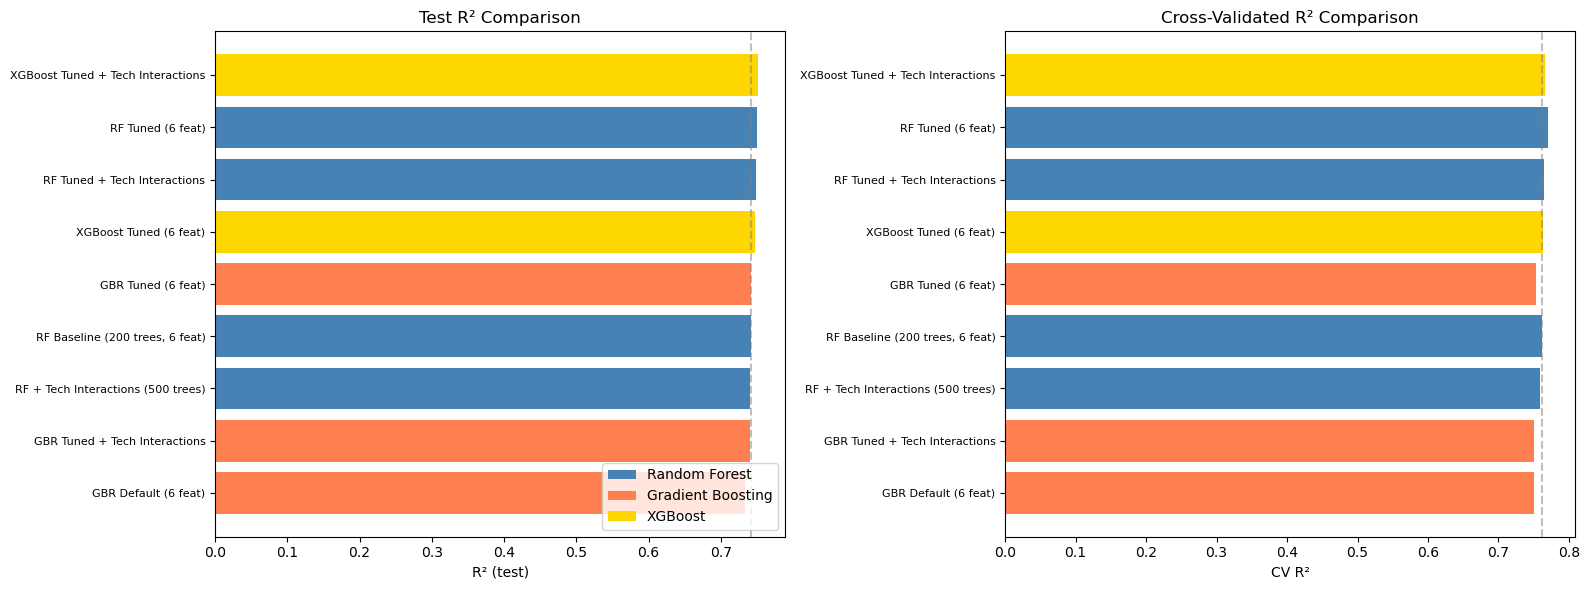

In [18]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comp_sorted = comp.sort_values('R² (test)', ascending=True)

# Color by model type
def get_color(name):
    if 'XGB' in name: return 'gold'
    if 'GBR' in name: return 'coral'
    return 'steelblue'

colors = [get_color(n) for n in comp_sorted.index]

axes[0].barh(range(len(comp_sorted)), comp_sorted['R² (test)'], color=colors)
axes[0].set_yticks(range(len(comp_sorted)))
axes[0].set_yticklabels(comp_sorted.index, fontsize=8)
axes[0].set_xlabel('R² (test)')
axes[0].set_title('Test R² Comparison')
axes[0].axvline(x=baseline_r2, color='gray', linestyle='--', alpha=0.5)

axes[1].barh(range(len(comp_sorted)), comp_sorted['CV R²'], color=colors)
axes[1].set_yticks(range(len(comp_sorted)))
axes[1].set_yticklabels(comp_sorted.index, fontsize=8)
axes[1].set_xlabel('CV R²')
axes[1].set_title('Cross-Validated R² Comparison')
axes[1].axvline(x=results[0]['cv_r2'], color='gray', linestyle='--', alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Random Forest'),
                   Patch(facecolor='coral', label='Gradient Boosting'),
                   Patch(facecolor='gold', label='XGBoost')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## Predicted vs Actual: Best Models

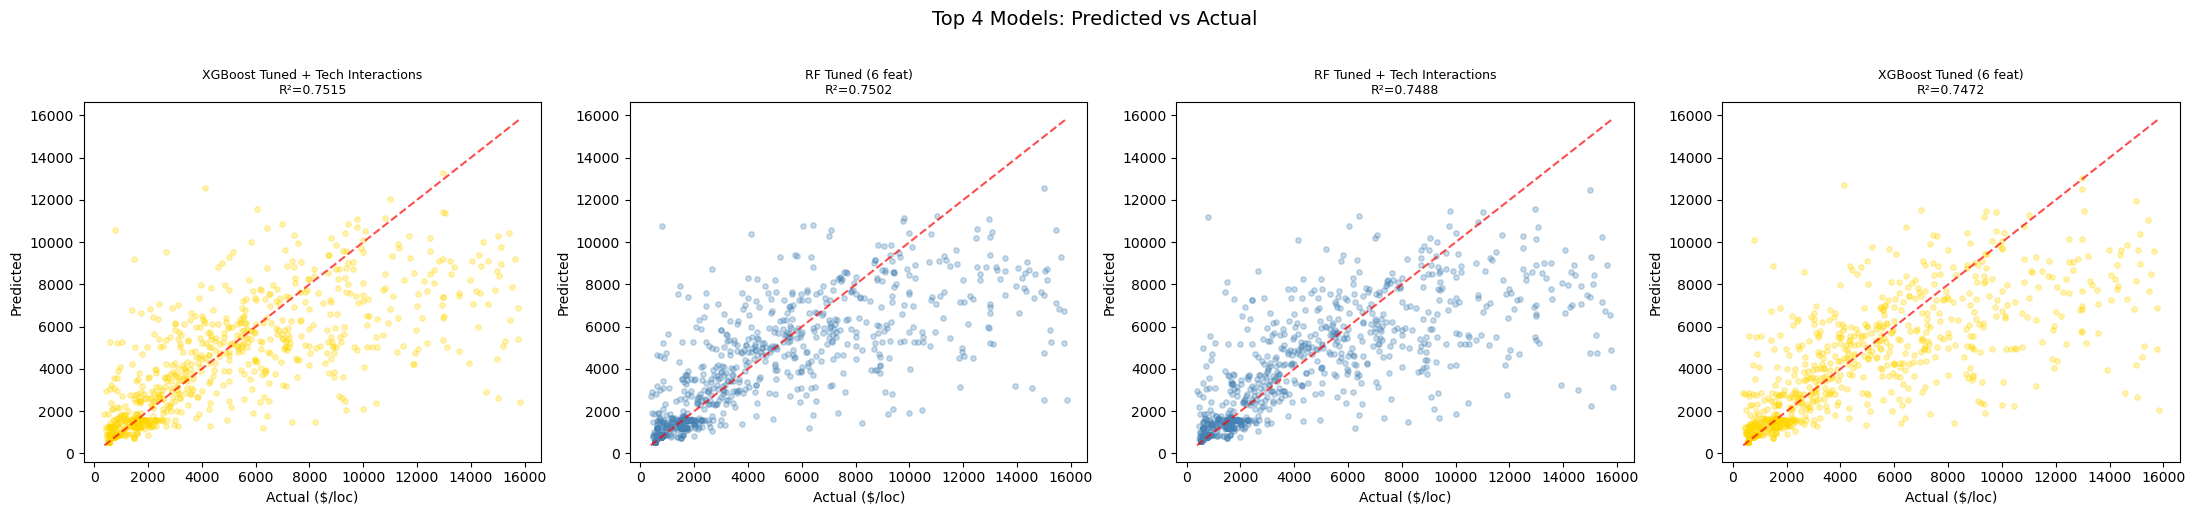

In [19]:
# Show top 4 models
top_results = sorted(results, key=lambda x: x['r2'], reverse=True)[:4]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, r in zip(axes, top_results):
    actual = np.expm1(y_test)
    predicted = np.expm1(r['y_pred'])
    color = get_color(r['name'])
    
    ax.scatter(actual, predicted, alpha=0.3, s=15, color=color)
    lims = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlabel('Actual ($/loc)')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{r["name"]}\nR²={r["r2"]:.4f}', fontsize=9)

plt.suptitle('Top 4 Models: Predicted vs Actual', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Feature Importance: Best RF vs Best GBR

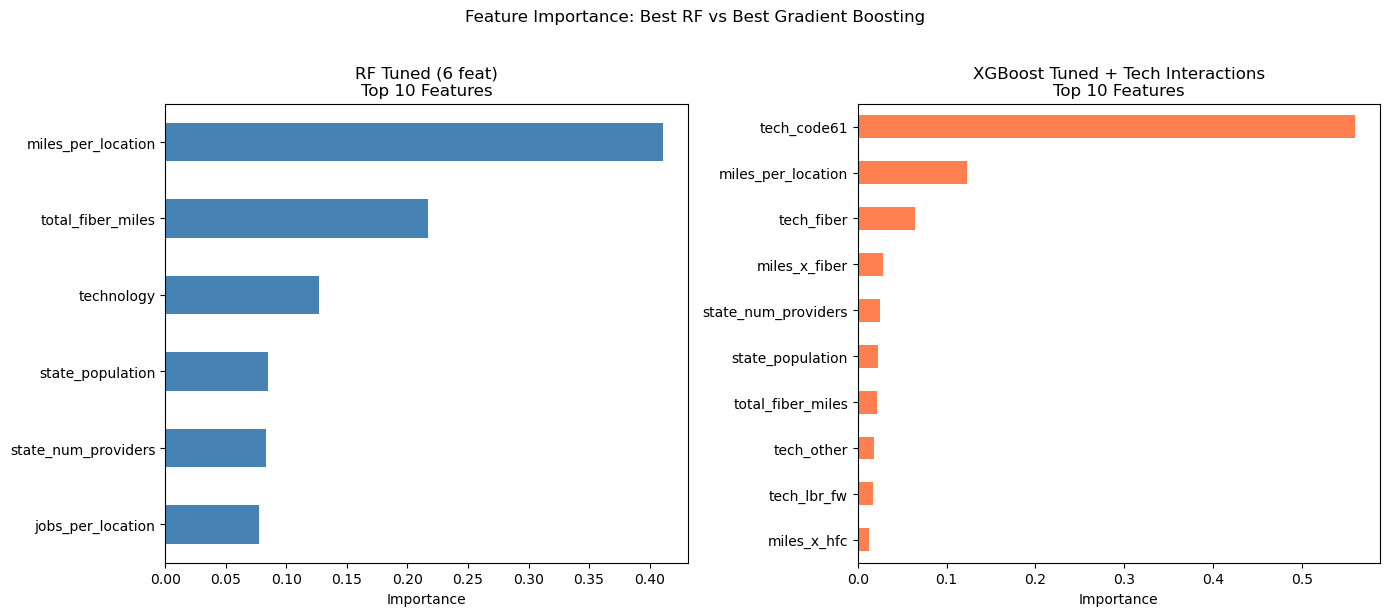

In [20]:
# Compare feature importance between best RF and best gradient boosting
best_rf = next(r for r in sorted(results, key=lambda x: x['r2'], reverse=True) 
               if 'RF' in r['name'])
best_gb = next(r for r in sorted(results, key=lambda x: x['r2'], reverse=True)
               if 'GBR' in r['name'] or 'XGB' in r['name'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Best RF importance
rf_model = best_rf['model']
if hasattr(rf_model, 'best_estimator_'):
    rf_model = rf_model.best_estimator_
rf_feat = feat_enhanced if 'Interaction' in best_rf['name'] else feat_original
rf_imp = pd.Series(rf_model.feature_importances_, index=rf_feat).sort_values()
rf_imp.tail(10).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title(f'{best_rf["name"]}\nTop 10 Features')
axes[0].set_xlabel('Importance')

# Best GB importance
gb_model = best_gb['model']
if hasattr(gb_model, 'best_estimator_'):
    gb_model = gb_model.best_estimator_
gb_feat = feat_enhanced if 'Interaction' in best_gb['name'] else feat_original
gb_imp = pd.Series(gb_model.feature_importances_, index=gb_feat).sort_values()
gb_imp.tail(10).plot.barh(ax=axes[1], color='coral')
axes[1].set_title(f'{best_gb["name"]}\nTop 10 Features')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance: Best RF vs Best Gradient Boosting', y=1.02)
plt.tight_layout()
plt.show()

## SHAP: Best Model

SHAP analysis for best model: XGBoost Tuned + Tech Interactions (R²=0.7515)


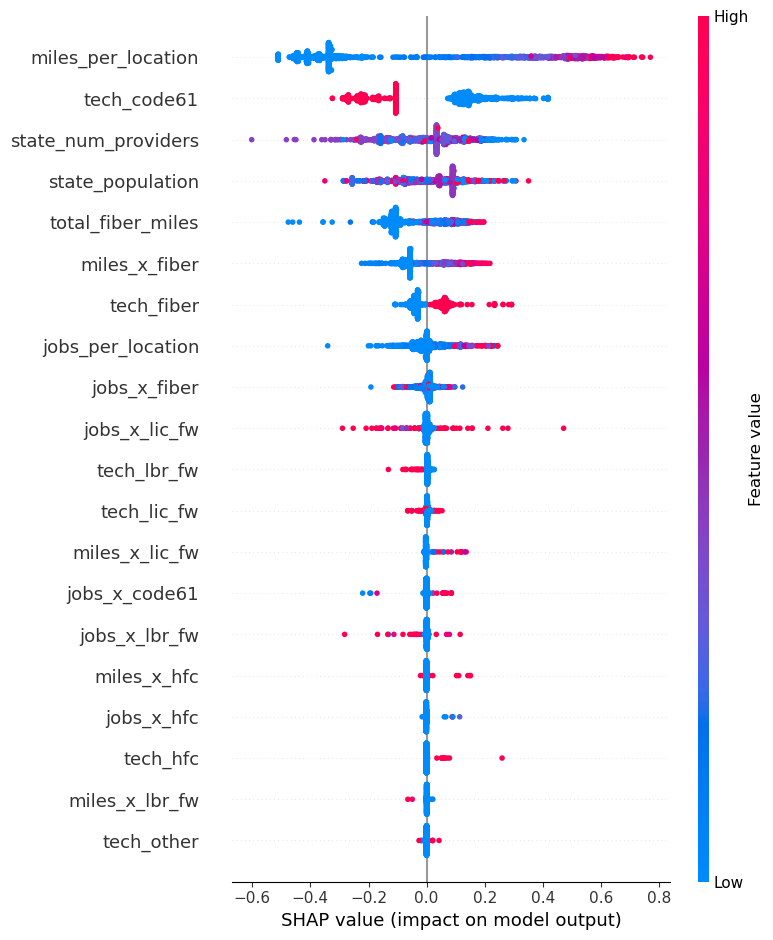

In [21]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap

best = sorted(results, key=lambda x: x['r2'], reverse=True)[0]
best_model = best['model']
if hasattr(best_model, 'best_estimator_'):
    best_model = best_model.best_estimator_

best_feat = feat_enhanced if 'Interaction' in best['name'] else feat_original
X_te_best = X_enh_test if 'Interaction' in best['name'] else X_orig_test

print(f'SHAP analysis for best model: {best["name"]} (R²={best["r2"]:.4f})')

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_te_best)

shap.summary_plot(shap_values, X_te_best, feature_names=best_feat, show=True)

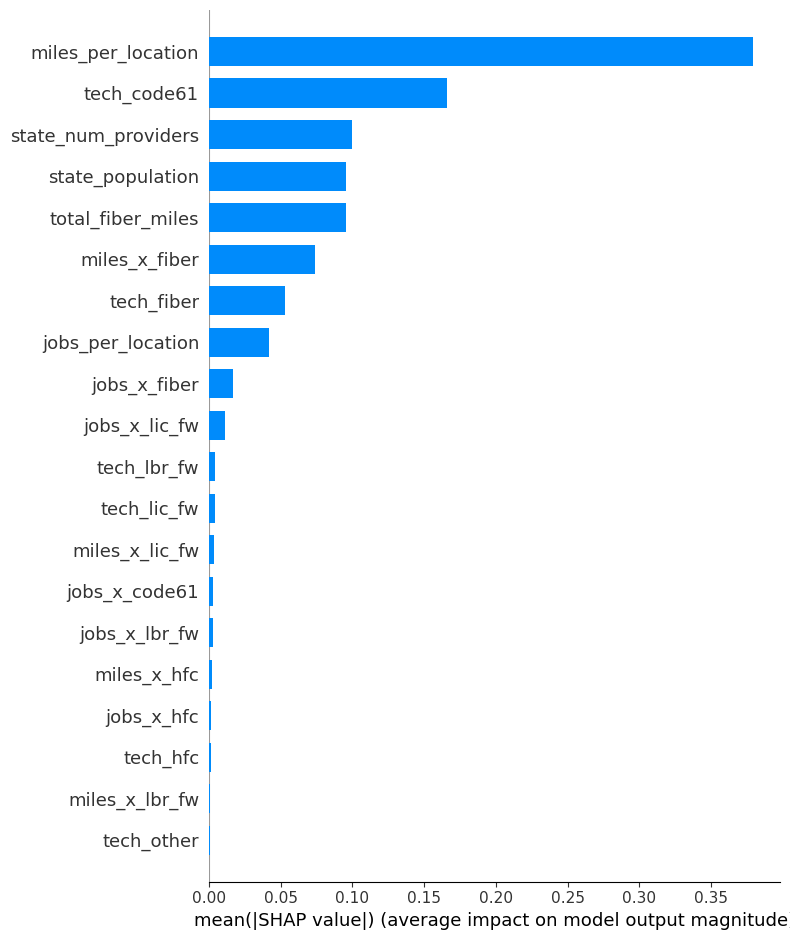

In [22]:
shap.summary_plot(shap_values, X_te_best, feature_names=best_feat, plot_type='bar', show=True)

## Final Summary

In [23]:
print('=' * 70)
print('MODEL IMPROVEMENT SUMMARY')
print('=' * 70)

comp_final = comp.sort_values('R² (test)', ascending=False)

print(f'\n{"Rank":<5} {"Model":<40} {"R²":>6} {"vs Base":>8} {"CV R²":>6} {"RMSE":>8}')
print('-' * 75)
for i, (name, row) in enumerate(comp_final.iterrows(), 1):
    delta = row['R² vs Baseline']
    print(f'{i:<5} {name:<40} {row["R² (test)"]:>6.4f} {delta:>+8.4f} {row["CV R²"]:>6.4f} ${row["RMSE ($)"]:>7,.0f}')

best_name = comp_final.index[0]
best_row = comp_final.iloc[0]

print(f'\n--- Key Takeaways ---')
print(f'Best model: {best_name}')
print(f'  R² improvement over baseline: {best_row["R² vs Baseline"]:+.4f}')
print(f'  RMSE: ${best_row["RMSE ($)"]:,.0f} (baseline: ${results[0]["rmse"]:,.0f})')

# Check if GB outperforms RF
best_rf_r2 = max(r['r2'] for r in results if 'RF' in r['name'])
best_gb_r2 = max(r['r2'] for r in results if 'GBR' in r['name'] or 'XGB' in r['name'])

if best_gb_r2 > best_rf_r2:
    print(f'\nGradient boosting outperforms Random Forest (R² {best_gb_r2:.4f} vs {best_rf_r2:.4f})')
    print('GB focuses on hard-to-predict cases by building trees sequentially.')
else:
    print(f'\nRandom Forest matches or beats gradient boosting (R² {best_rf_r2:.4f} vs {best_gb_r2:.4f})')
    print('With this dataset size, RF bagging is competitive with sequential boosting.')

# Check if interactions help
best_plain = max(r['r2'] for r in results if 'Interaction' not in r['name'])
best_inter = max(r['r2'] for r in results if 'Interaction' in r['name'])

if best_inter > best_plain:
    print(f'\nTech interaction features help (+{best_inter - best_plain:.4f} R²).')
    print('The model benefits from explicitly modeling technology-specific cost patterns.')
else:
    print(f'\nTech interaction features did not help ({best_inter - best_plain:+.4f} R²).')
    print('Tree models can learn interactions implicitly via splits.')

MODEL IMPROVEMENT SUMMARY

Rank  Model                                        R²  vs Base  CV R²     RMSE
---------------------------------------------------------------------------
1     XGBoost Tuned + Tech Interactions        0.7515  +0.0096 0.7668 $  2,458
2     RF Tuned (6 feat)                        0.7502  +0.0083 0.7705 $  2,444
3     RF Tuned + Tech Interactions             0.7488  +0.0069 0.7645 $  2,468
4     XGBoost Tuned (6 feat)                   0.7472  +0.0053 0.7636 $  2,452
5     GBR Tuned (6 feat)                       0.7422  +0.0003 0.7535 $  2,496
6     RF Baseline (200 trees, 6 feat)          0.7419  +0.0000 0.7622 $  2,491
7     RF + Tech Interactions (500 trees)       0.7410  -0.0010 0.7593 $  2,488
8     GBR Tuned + Tech Interactions            0.7408  -0.0011 0.7500 $  2,527
9     GBR Default (6 feat)                     0.7331  -0.0089 0.7511 $  2,527

--- Key Takeaways ---
Best model: XGBoost Tuned + Tech Interactions
  R² improvement over baseline: +0.009